In [17]:
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from heisenberg_hamiltonians import HeisenbergJ1J2
from mvmc_configs import MVMCConfig
from spin_lattices import KagomeLattice, SquareLattice
from mvmc_kagome_2023_03_29 import system, experiment_dir

import matplotlib.pyplot as plt
import seaborn as sns


In [16]:
%matplotlib inline

In [24]:
outfiles = pd.concat(
    [
        pd.read_csv(out_file, index_col=0)
        .reset_index()
        .assign(trial=out_file.stem.removeprefix("out_"))
        for out_file in ((experiment_dir / "out").glob("*.csv"))
    ],
    ignore_index=True,
)
outfiles = (
    outfiles.merge(
        (outfiles.groupby("trial").size() == 500).rename("good"), left_on="trial", right_index=True
    )
    .query("good")
    .drop("good", axis=1)
)


(-11.0, -10.0)

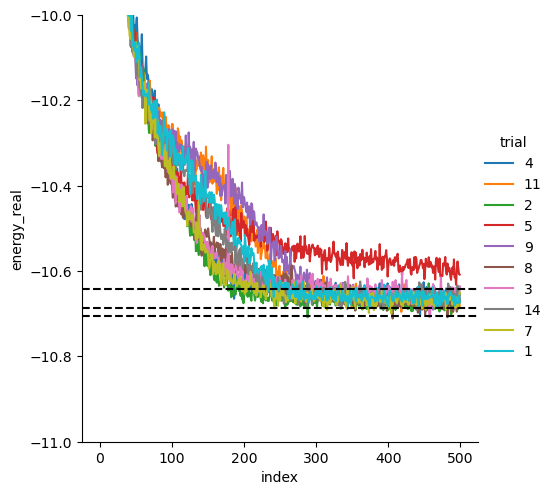

In [46]:
sns.relplot(outfiles, x="index", y="energy_real", hue="trial", kind="line")
plt.axhline(system.get_eigenstates(4)[0][0] / 4, color="black", linestyle="--")
plt.axhline(system.get_eigenstates(4)[0][1] / 4, color="black", linestyle="--")
plt.axhline(system.get_eigenstates(4)[0][2] / 4, color="black", linestyle="--")

plt.ylim(-11, -10)


In [61]:
outfiles.sort_values("energy_real")

,index,energy_real,energy_imag,energy_square,energy_variance,sz,sz_squared,trial
2910,406,-10.711317,0.0,114.891540,0.001388,0.0,0.0,8
1291,288,-10.708376,0.0,114.732231,0.000549,0.0,0.0,2
2986,482,-10.708259,0.0,114.804335,0.001199,0.0,0.0,8
3462,457,-10.707906,0.0,117.618501,0.025809,0.0,0.0,3
3463,458,-10.706773,0.0,116.027981,0.012152,0.0,0.0,3
...,...,...,...,...,...,...,...,...
4505,0,-9.508945,0.0,90.973695,0.006123,0.0,0.0,1
4506,1,-9.501802,0.0,90.781054,0.005503,0.0,0.0,1
1004,1,-9.501707,0.0,90.892484,0.006757,0.0,0.0,2
2504,0,-9.497264,0.0,90.925171,0.008062,0.0,0.0,8


In [49]:
pd.read_csv(experiment_dir / "wavefunctions" / f"wavefunction_{0}.csv")


,idx,eigenstate_coeff
0,4095,-0.000202
1,6143,-0.000305
2,7167,0.000013
3,7679,0.000874
4,7935,-0.000118
...,...,...
2704151,16769280,-0.000122
2704152,16769536,0.000860
2704153,16770048,0.000030
2704154,16771072,-0.000270


In [50]:
wavefunctions = {
    trial: pd.read_csv(experiment_dir / "wavefunctions" / f"wavefunction_{trial}.csv").set_index(
        "idx"
    )["eigenstate_coeff"]
    for trial in outfiles["trial"].unique()
}


In [107]:
system.get_eigenstates(6)

2023-03-30 17:18:25.962 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:94 - Calculating eigenvalues / eigenstates
2023-03-30 17:18:52.207 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:107 - Ground state energy is -42.8245991763


(array([-42.82459918, -42.7457909 , -42.56683915, -41.55803916,
        -41.52579075, -41.45614383]),
 array([[ 3.68841196e-07,  1.92582557e-07,  4.49278916e-08,
          2.90715316e-07,  1.53180338e-07,  3.13345920e-07],
        [ 1.08484503e-07,  9.43463455e-10, -1.27913545e-07,
          1.50491895e-06, -5.60370852e-07, -2.02857488e-06],
        [-7.83438144e-18, -6.65075349e-08, -1.24715514e-07,
          7.67112673e-07, -7.21728319e-18,  3.84904958e-07],
        ...,
        [-1.41331441e-05, -3.95273861e-04,  3.19659312e-02,
          2.73603425e-02,  1.46598885e-02, -2.59451434e-03],
        [-1.67384289e-02,  6.44579328e-04,  3.03936358e-02,
          1.96179886e-02,  2.62700944e-02,  7.78334041e-04],
        [ 3.56623895e-02,  1.85038874e-04,  1.68608469e-02,
          1.08282185e-02,  1.88418029e-02,  6.10945839e-04]]))

In [124]:
ed_eigenstates = [system.get_df_eigenstate(canonical_basis=True, k=k)["eigenstate_coeff"] for k in range(6)]


In [117]:
(list(wavefunctions.values())[0].index == ed_eigenstate.index).all()

True

In [118]:
[
    sum(np.sign(wavefunction.values) * np.sign(ed_eigenstate.values) * ed_eigenstate.values**2)
    for trial, wavefunction in wavefunctions.items() if trial == "8"
]


[-0.0011988298629760981]

In [119]:
(np.sign(wavefunctions['8'].values) == np.sign(ed_eigenstate.values)).mean()

0.5011981557277021

In [ ]:
system_nosym = HeisenbergJ1J2(
    KagomeLattice(2, 4), J1=1.0, J2=1.0, ground_state_cache_dir=Path("groundstates"),
    use_symmetries=False, spin_inversion=None
)

In [128]:
for es1 in ed_eigenstates:
    es2 = wavefunctions['8']
    print("Overlap", sum(es1.values * (es2.values))  / np.linalg.norm(es1.values) / np.linalg.norm(es2.values))
    print("Energy", np.dot((system_nosym.hamiltonian @ es1.values), es1.values) / 4)
print("Energy ED", np.dot((system_nosym.hamiltonian @ es2.values), es2.values) / 4)

Overlap 0.012020048219264974
Energy -10.706149794063277
Overlap 0.0007259248201351602
Energy -10.6864477257677
Overlap 0.13184813609645324
Energy -10.641709787146285
Overlap -0.0021259266251637053
Energy -10.389509788851786
Overlap -0.015068978334767428
Energy -10.381447687618817
Overlap -0.00042582927536902735
Energy -10.36403595707677
Energy ED -10.66857432426659


In [130]:
(-10.66857432426659 - (-10.706149794063277)) / (-10.706149794063277)

-0.00350970895414927

In [122]:
np.dot((system_nosym.hamiltonian @ ed_eigenstate.values), ed_eigenstate.values) / 4

-10.364035957076768

In [129]:
system_nosym.get_eigenstates(10)

2023-03-30 17:32:00.307 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:94 - Calculating eigenvalues / eigenstates
2023-03-30 17:45:18.860 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:107 - Ground state energy is -43.0395889923


(array([-43.03958899, -42.82459918, -42.7457909 , -42.64435572,
        -42.638814  , -42.638814  , -42.56683915, -42.56683915,
        -42.56683915, -42.34783072]),
 array([[ 4.90411613e-09,  6.52025278e-08,  3.40441081e-08, ...,
          3.10850235e-09,  1.62077234e-08,  1.75996851e-08],
        [ 2.80245214e-08,  1.91775319e-08,  1.66782353e-10, ...,
          1.19297566e-09,  6.99751282e-08, -8.55468716e-08],
        [ 4.11419221e-19,  1.86579185e-18, -1.17569822e-08, ...,
         -1.36109137e-08,  2.42753447e-08, -4.70584705e-19],
        ...,
        [-2.25499309e-20, -1.76496527e-18, -1.17569822e-08, ...,
         -1.36109137e-08,  2.42753447e-08,  4.84731975e-19],
        [ 2.80245213e-08,  1.91775319e-08,  1.66782350e-10, ...,
          1.19297566e-09,  6.99751282e-08, -8.55468716e-08],
        [ 4.90411612e-09,  6.52025278e-08,  3.40441081e-08, ...,
          3.10850235e-09,  1.62077234e-08,  1.75996851e-08]]))